# CS/ECE 181: Programming Assignment #3

<small>v1.0.0</small>

**DUE DATE**: December 8, 11:59pm Pacific via GauchoSpace

* You can save a copy of this document in your own Drive and work on it in your own Colab
* You can add comments, multiple cells, etc. Just make sure to explain what you did so that we can give you partial credit.
* Make sure to rely only on allowed Python libraries. Each problem will state what's allowed.
* Remember, you are expected to work alone. You can ask questions on Piazza or discuss a solution approach with your peers, but you must not copy their code.
The implementation must be yours. **The use of AI-based tools is not allowed.** Assignments that were generated with the use of AI will receive 0 points.
* When you're done, go to "Runtime > Restart session and run all" to make sure your notebook runs correctly from top to bottom.
* **You need to submit two things: an .ipynb and .pdf file.** Go to "Download > Download .ipynb" to download the raw Jupyter Notebook file. Then go to "Print > Save as PDF" (or similar). **Make sure the files were produced correctly - meaning your solutions and generated images are visible.** We can only grade what you submit. Then upload both files to the Project 3 Assignment folder.

# 1. Getting Started with Keras (6 pts)

## 1.1 Intro to Keras

Keras is a deep learning API written in Python, running on top of the machine learning platform [TensorFlow](https://www.tensorflow.org/). It was developed with a focus on enabling fast experimentation.

If you're unfamiliar with TensorFlow, we have already seen a little bit of it in action when we messed around with the [TensorFlow Playgroun](https://playground.tensorflow.org).
TensorFlow is an end-to-end, open-source machine learning platform. You can think of it as an infrastructure layer for differentiable programming. It combines four key abilities:
- Efficiently executing low-level tensor operations on CPU, GPU, or TPU.
- Computing the gradient of arbitrary differentiable expressions.
- Scaling computation to many devices (e.g. the Summit supercomputer at Oak Ridge National Lab, which spans 27,000 GPUs).
- Exporting programs ("graphs") to external runtimes such as servers, browsers, mobile and embedded devices.

Like many other useful tools, Keras comes pre-installed with Google Colab:

In [ ]:
!pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 993.7/993.7 kB 10.7 MB/s eta 0:00:00


In [ ]:
from tensorflow import keras

The core data structures of Keras are `layers` and `models`. The simplest type of model is the `Sequential` model, a linear stack of layers.



In [ ]:
from tensorflow.keras.models import Sequential

In [ ]:
import visualkeras

## 1.2 Generating a toy dataset

Before we can build a useful model, we need some data.

We'll be using [scikit-learn](https://scikit-learn.org) for this - because it provides an easy way to generate some sample data.

Let's generate 500 data points lying on one of two concentric circles. The data points on the inner circle will be of class 0 and data points on the outer circle will be of class 1. We'll also add a little bit of noise:



In [ ]:
from sklearn.datasets import make_circles
X, y = make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42)
print(X.shape)
print(y.shape)

(500, 2)
(500,)


It is custom to call the feature matrix `X` (or `X_train`, `X_test`) and the vector of target labels (classes) `y` (or `y_train`, `y_test`).
You can see from the above output that our feature matrix `X` has shape 500x2, meaning it has 500 data points with two features each.
The `y` vector simply stores the target label for each data point, so it should have shape 500x1.

We can visualize the data as follows:

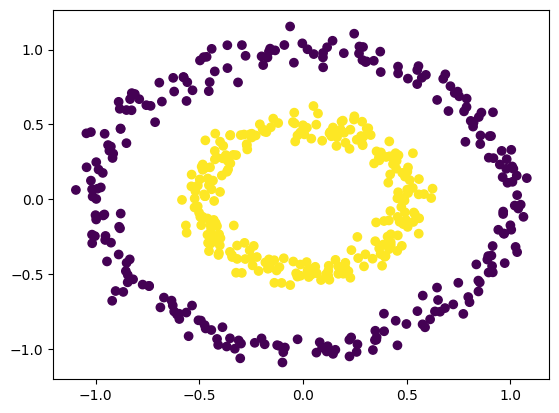

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=y)

Now we're ready to build our first neural network.

We'll start with an empty `Sequential` model and then add two layers:
- The first layer has 4 neurons in it: both input features are connected to all neurons in the layer. This is known as an "all-to-all" or "dense" connection. Hence we use the `Dense` layer. We'll add a ReLU as activation function.
- The second layer has 2 neurons in it: all 4 neurons of the previous layer are connected to both neurons in this layer. This is again a `Dense` layer with a ReLU activation function:
- The output layer has a single neuron in it: its activation will determine the class we're predicting (activation < 0.5: class 0, activation >= 0.5, class 1)

In [ ]:
from tensorflow.keras.layers import Dense, Input

model = Sequential()
model.add(Input(shape=(2,)))
model.add(Dense(4, activation='relu'))  # model.add(Dense(4, activation='relu', input_shape=(2,0)))
model.add(Dense(2, activation='relu'))
model.add(Dense(1, activation='sigmoid')) # one-hot encoding

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 4)                   │              12 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │              10 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25 (100.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
visualkeras.layered_view(model)

/usr/local/lib/python3.10/dist-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


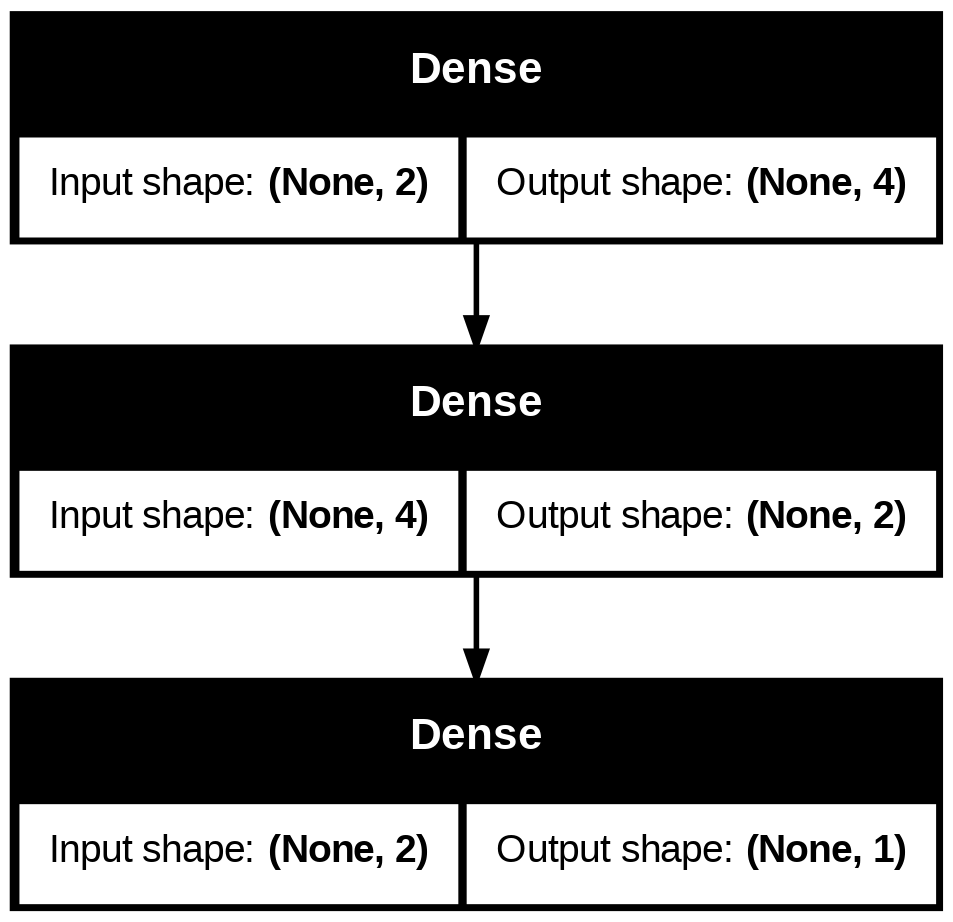

In [ ]:
keras.utils.plot_model(model, show_shapes=True)

To allocate the weights, each layer needs to know the number of its inputs. In a hidden layer, this is inferred automatically. However, the first layer can't automatically guess what input data you're going to present, so you need to tell it the right `input_shape` or define an `Input layer` as we have done before your first hidden layer.

By default, each layer uses a bias vector (`use_bias=True`), whose values do not depend on the input features. This allows the layer to do calculate `y_hat=ReLU(ax+b)` instead of just `y_hat=ReLU(ax)`.



## 1.3 **TODO:** Differences to TensorFlow Playground (2 pts)

Guess what! This is (almost) the same as the default network you see when you first open [TensorFlow Playground](https://playground.tensorflow.org).
We're not sure what loss function they used, or whether they included a bias vector. But what are some other differences between ours and Playground?

Name at least two:

---

**YOUR ANSWER HERE (2 pts)**: TensorFlow Playground uses the tanh activation function, while we're using the ReLU and softmax activation functions. They also use a training validation set, whereas we're not splitting the dataset.

---

## 1.4 **TODO:** Training the model (4 pts)

Now we are ready to train the model.

First we need to build it by translating the network specifications above into an executable network. This is done with `compile`. Here we have the option to specify which [loss function](https://keras.io/api/losses/) to use (e.g., mean squared error), which [solver](https://keras.io/api/optimizers/) to use (e.g., stochastic gradient descent, adam), which metrics to output (e.g., accuracy), etc.

Since this is a classification task, we want to use the cross-entropy loss.

What are some other loss functions that work for classification? Name at least two:


---

**YOUR ANSWER HERE (3 pts)**: Some other loss functions that work for classification are hinge loss, sigmoid cross-entropy loss, square loss, and Kullback-Leibler divergence.

---

We'll also use stochastic gradient descent (SGD) with a 0.03 learning rate (just like Playground):


In [ ]:
model.compile(loss='binary_crossentropy', optimizer=keras.optimizers.SGD(learning_rate=0.03),
              metrics=['accuracy'])

Then we're ready to train the model using the same batch size as Playground.

But what does batch size 10 mean?

---

**YOUR ANSWER HERE (1 pt)**: Batch size 10 means that we're testing 10 data points at a time.

---

We will also hold out 20% of the training data as a "validation set". This validation set serves a similar purpose as the test set - to monitor the model's generalization error as training progress. Often training is stopped as soon as the validation error does not decrease after a few iteration (aka "early stopping"). This allows you to specify a "large enough" number for the number of iterations, and early stopping will make sure to quit the training process as soon as the validation error does not get better.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
history = model.fit(X, y, batch_size=10, epochs=300, validation_split=0.2)
                    # callbacks=[EarlyStopping(monitor='val_loss', patience=5)]) can also add Tensorboard here which is Tf's visualization toolkit

Epoch 1/300
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.4540 - loss: 0.6933 - val_accuracy: 0.4500 - val_loss: 0.6939
Epoch 2/300
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4709 - loss: 0.6935 - val_accuracy: 0.4500 - val_loss: 0.6946
Epoch 3/300
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5394 - loss: 0.6925 - val_accuracy: 0.4500 - val_loss: 0.6950
Epoch 4/300
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5011 - loss: 0.6935 - val_accuracy: 0.4500 - val_loss: 0.6953
Epoch 5/300
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5376 - loss: 0.6921 - val_accuracy: 0.4500 - val_loss: 0.6954
Epoch 6/300
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5466 - loss: 0.6916 - val_accuracy: 0.4500 - val_loss: 0.6954
Epoch 7/300
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5244 - loss: 0.6926 - val_accuracy: 0.4500 - val_loss: 0.6955
Epoch 8/300
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4898 - loss: 0.6941 - val_accuracy: 0.4500 

We can now use the `history` variable to visualize the progression of the loss (and the validation loss) over time:


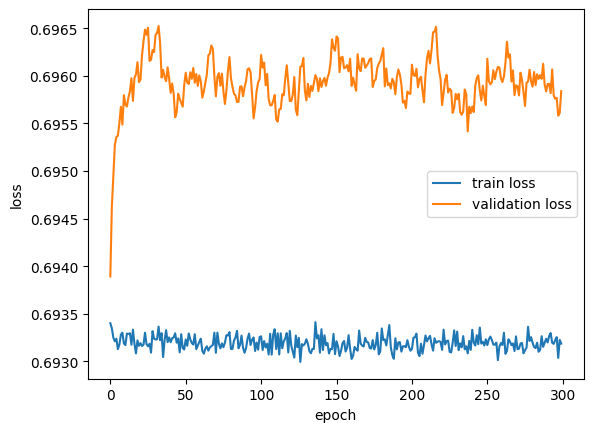

In [ ]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

## 1.5 Plotting the decision boundaries

Your network should achieve 100% accuracy after 200 epochs. We could look at some other metrics to convince ourselves that the network did a good job. Or we could visualize the decision boundaries, like TensorFlow Playground does.

There are probably some useful third-party libraries for this, but in principle, the idea is to feed all possible combinations of input features to the model and look at the predictions:

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


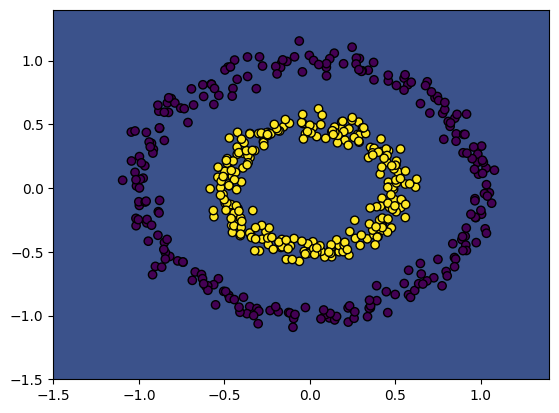

In [ ]:
# Create a mesh grid of (x1,x2) feature values:
import numpy as np
x1, x2 = np.meshgrid(np.arange(-1.5, 1.5, 0.1),
                     np.arange(-1.5, 1.5, 0.1))

# Have the model predict the labels:
zz = model.predict(np.vstack((x1.ravel(), x2.ravel())).T)

# Convert from one-hot encoding back to [0, 1] labels:
zz = np.int32(zz[:, 0] >= 0.5).reshape(x1.shape)

# Plot it:
plt.contourf(x1, x2, zz)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')

You should see that all yellow data points lie in the yellow region, and all blue data points lie in the blue region. This confirms that the network correctly classified all data points!

Now let's look at a more complicated example.

In [ ]:
model_example = keras.Sequential([
    keras.Input(shape=(50,50,0)),

    keras.layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

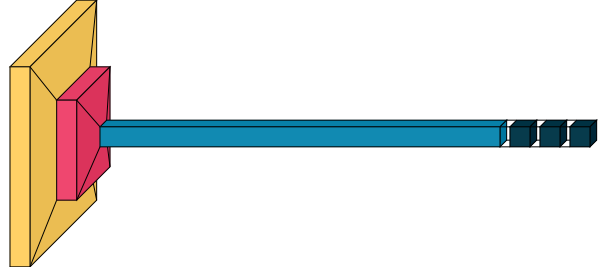

In [ ]:
visualkeras.layered_view(model_example)

<hr>

# 2. Getting Started with CNNs (10 pts)

In this section we want to build a CNN for handwritten digit classification using the MNIST dataset.

## 2.1 Loading the MNIST dataset

The first step is to load the dataset. Fortunately, it comes bundled with Keras:

In [ ]:
from keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


The dataset has already been split into training and test data. Printing the shape of these variables reveals the size of the dataset:

In [ ]:
print('Training set:', X_train.shape)
print('Test set:', X_test.shape)

Training set: (60000, 28, 28)
Test set: (10000, 28, 28)


From this we can see that MNIST contains 60,000 training samples and 10,000 test samples. Each image is 28x28 pixels.

For each of these training samples, we also have a class label indicating which digit this image is shown (0-9).

To make this dataset work with Keras, we need to make sure input image size is 28x28x1, not 28x28. We'll also scale the images to the [0,1] range:

In [ ]:
# Scale to [0,1]:
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

# Make sure images have shape (28, 28, 1):
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

Finally, we need to transform the labels, from an integer 0-9 to a vector of zeros and ones (one-hot encoding), similar to the last homework.

The reason is that our network will have 10 output neurons. If the first neuron is active, it means we are predicting the first class (digit 0). If the last neuron is active, we predict digit 9. etc.

For this to work, we need a vector where all entries are zero except for the one that corresponds to the class we want to predict.
For example, predicting digit 0 would be represented as follows:

    [1 0 0 0 0 0 0 0 0]

The digit 1 would be represented as follows:

    [0 1 0 0 0 0 0 0 0]

In other words, with this one-hot encoding we are telling the network that all neurons in the output layer should be silent - except the first one if we want to predict digit 0, or the second one if we want to predict digit 1, etc.

However, we don't have to do this from scratch anymore - we can use a utility function:

In [ ]:
# For future reference:
num_classes = len(np.unique(y_train))
img_shape = X_train.shape[1:]

from keras.utils import to_categorical
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

## 2.2 **TODO:** Building our first model (5 pts)

Now on to the network architecture. We will start simple:

- Add a single convolutional layer with 3x3 kernels and ReLU activation.
- Add a max pooling layer with 2x2 pool size and stride 2
- Add a dense layer with softmax activation.

In [ ]:
from keras import layers

model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),

    keras.layers.Conv2D(filters=4, kernel_size=(3, 3), padding='same', activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    keras.layers.Flatten(),
    keras.layers.Dense(10, activation='softmax')
])

**TODO:** How many trainable parameters does the movel have?

> Hint: Have a look at `model.summary`

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)                    │ (None, 28, 28, 4)           │              40 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 4)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 10)                  │           7,850 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,890 (30.82 KB)

 Trainable params: 7,890 (30.82 KB)

 Non-trainable params: 0 (0.00 B)

---

**YOUR ANSWER HERE (1 pt):** The model has 7,890 trainable parameters.

---

## 2.3 Training the model (3 pts)

OK let's train the model and see how good it is.

We'll use stochastic gradient descent with batch size 128. We'll train for at least 50 epochs (but use early stopping; and you're welcome to run longer) and calculate accuracy. Each epoch should only take 15 seconds, so this might take 12-15 minutes to run.


In [ ]:
model.compile(loss='binary_crossentropy', optimizer=keras.optimizers.SGD(learning_rate=0.03),
              metrics=['accuracy'])

history = model.fit(X_train, y_train, batch_size=128, epochs=50, validation_split=0.2, callbacks=[EarlyStopping(monitor='val_loss', patience=5)])

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.2666 - loss: 0.3981 - val_accuracy: 0.7302 - val_loss: 0.2195
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - accuracy: 0.7429 - loss: 0.1975 - val_accuracy: 0.8258 - val_loss: 0.1383
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.8202 - loss: 0.1369 - val_accuracy: 0.8583 - val_loss: 0.1106
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.8505 - loss: 0.1130 - val_accuracy: 0.8733 - val_loss: 0.0974
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.8651 - loss: 0.1011 - val_accuracy: 0.8806 - val_loss: 0.0899
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.8687 - loss: 0.0954 - val_accuracy: 0.8881 - val_loss: 0.0849
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.8764 - loss: 0.0901 - val_accuracy: 0.8925 - val_loss: 0.0814
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.8809 - loss: 0.0870 - 

Plot the training and validation error in each epoch of the training process:

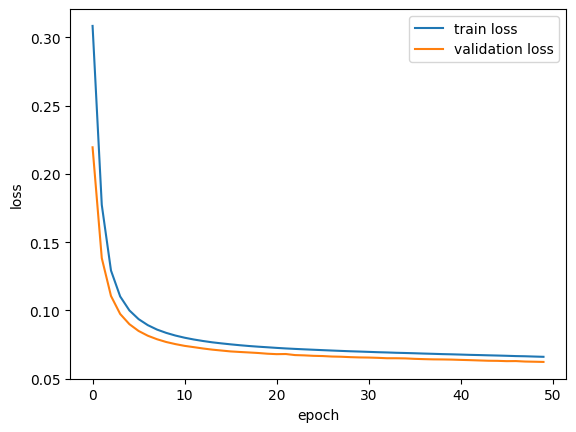

In [ ]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

## 2.4 **TODO**: Evaluating the model (2 pts)

In the cell below, print the loss and accuracy on train and tests:

> Hint: Have a look at `model.evaluate`

In [ ]:
train_results = model.evaluate(X_train, y_train)
test_results = model.evaluate(X_test, y_test)

train_loss = train_results[0]
train_acc = train_results[1]
test_loss = test_results[0]
test_acc = test_results[1]

print("Train Loss:", train_loss)
print("Train Accuracy:", train_acc)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9137 - loss: 0.0647
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9056 - loss: 0.0697
Train Loss: 0.06502848863601685
Train Accuracy: 0.9131166934967041
Test Loss: 0.06216361001133919
Test Accuracy: 0.9192000031471252


Are you overfitting or underfitting? Do the training/test accuracy agree with what you expected?

---

**YOUR ANSWER HERE (2 pts)**: The model is neither overfitting or underfitting. This is because both the training and testing data have similar accuracy and loss scores. If the model was overfitting, there would be a high accuracy for the training data, while the accuracy for the testing data would be significantly lower. If the model was underfitting, there would be a low accuracy for both the training and testing data.

---

# 3. Building LeNet-5 (20 pts)

A network with one convolutional layer is not exactly deep, so let's add some layers.

## 3.1 **TODO:** Building the network (10 pts)

In the cell(s) below, implement LeNet-5 as discussed in class.

To be clear, your network should look like this:



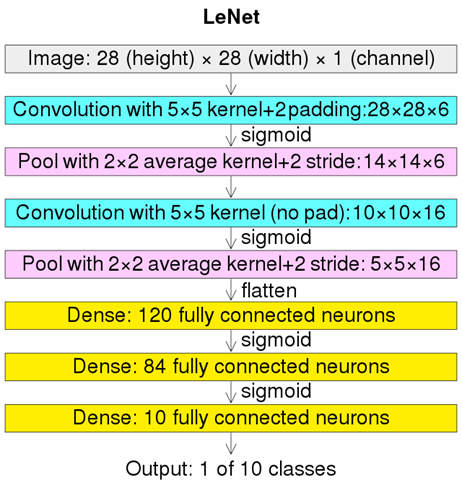

> Hints:
> - You'll have to specify the input shape for the first layer.
> - You can either specify the activation function as part of the convolutional/dense layer call, or add a stand-alone activation layer after it.
> - Instead of specifying number of pixels for `padding`, read the docs to figure out which string gives you the expected output.
> - Finally, don't forget to add a softmax activation after the last Dense layer.

In [ ]:
model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),

    keras.layers.Conv2D(filters=6, kernel_size=(5, 5), padding='same', activation="sigmoid"),
    keras.layers.AveragePooling2D(pool_size=(2, 2), strides=2),

    keras.layers.Conv2D(filters=16, kernel_size=(5, 5), activation="sigmoid"),
    keras.layers.AveragePooling2D(pool_size=(2, 2), strides=2),

    keras.layers.Flatten(),
    keras.layers.Dense(120, activation='sigmoid'),
    keras.layers.Dense(84, activation='sigmoid'),
    keras.layers.Dense(10, activation='softmax')
])

Print a model summary to make sure you got all the layers/dimensions right:

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 6)           │             156 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d (AveragePooling2D) │ (None, 14, 14, 6)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 10, 10, 16)          │           2,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_1                  │ (None, 5, 5, 16)            │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 400)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 120)                 │          48,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 84)                  │          10,164 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 10)                  │             850 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

How many trainable parameters does the model have? Which layer type is responsible for the majority of these parameters?

---

**YOUR ANSWER HERE**: The model has 61,706 trainable parameters. The second dense layer with 120 fully connected neurons is responsible for the majority of these parameters (specifically, 48,120 parameters).

---

## 3.2 **TODO:** Training the model (2 pts)

To train the model, use the categorical cross-entropy loss and the adam optimizer with a batch size of 128 or 256.
Train for at least 10 epochs (should take roughly 5 minutes).
Add accuracy as a metric.
Set aside 20% of your training data for validation.


Make sure to store the output of `model.fit` in a variable, so that you can plot the training and validation error as training progress (like we did in Section 1 above).

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer=keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

history = model.fit(X_train, y_train, batch_size=128, epochs=10, validation_split=0.2, callbacks=[EarlyStopping(monitor='val_loss', patience=5)])

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 32s 81ms/step - accuracy: 0.2004 - loss: 2.1811 - val_accuracy: 0.8359 - val_loss: 0.6184
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 39s 76ms/step - accuracy: 0.8603 - loss: 0.5095 - val_accuracy: 0.9153 - val_loss: 0.2970
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 42s 78ms/step - accuracy: 0.9167 - loss: 0.2905 - val_accuracy: 0.9372 - val_loss: 0.2172
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 78ms/step - accuracy: 0.9338 - loss: 0.2185 - val_accuracy: 0.9466 - val_loss: 0.1756
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 28s 76ms/step - accuracy: 0.9476 - loss: 0.1755 - val_accuracy: 0.9552 - val_loss: 0.1480
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 28s 76ms/step - accuracy: 0.9551 - loss: 0.1443 - val_accuracy: 0.9622 - val_loss: 0.1213
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 28s 76ms/step - accuracy: 0.9635 - loss: 0.1226 - val_accuracy: 0.9683 - val_loss: 0.1037
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 28s 75ms/step - accuracy: 0.9694 - loss: 0.1060 - 

## 3.3 **TODO**: Visualizing training progression (2 pts)

If you followed the hint above, you should have stored the output of `model.fit` in a variable. Now use this variable to visualize the progression of the loss (and the validation loss) over time.

Make sure to label your axes.

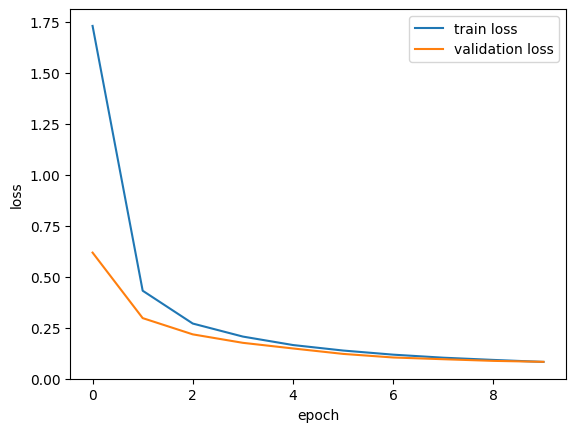

In [ ]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

## 3.4 **TODO**: Evaluating model performance (2 pts)

Now use your trained model to calculate the accuracy on the train and test set:

In [ ]:
train_results = model.evaluate(X_train, y_train)
test_results = model.evaluate(X_test, y_test)

train_loss = train_results[0]
train_acc = train_results[1]
test_loss = test_results[0]
test_acc = test_results[1]

print("Train Loss:", train_loss)
print("Train Accuracy:", train_acc)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9768 - loss: 0.0754
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9728 - loss: 0.0909
Train Loss: 0.07787539064884186
Train Accuracy: 0.9761166572570801
Test Loss: 0.08102218806743622
Test Accuracy: 0.975600004196167


Is the model underfitting or overfitting? Why?

---

**YOUR ANSWER HERE**: The model is neither overfitting or underfitting. This is because both the training and testing data have similar accuracy and loss scores. If the model was overfitting, there would be a high accuracy for the training data, while the accuracy for the testing data would be significantly lower. If the model was underfitting, there would be a low accuracy for both the training and testing data.

---

## 3.5 **TODO:** Visualizing what the network learns (4 pts)

In the cell(s) below, visualize the weigths that each neuron in the *first convolutional layer* learned. Ideally you would write a function that takes in the weights of a layer and then plots the learned weights for each neuron in the layer in a Matplotlib subplot.

> Hints:
> - You can access the weights of a layer with `model.layers[n].get_weights()[0]`, where `n` specifies the `n`-th layer in the network. Call `shape` on it to see its dimensions
> - Here's a recipe to make a 3x5 subplots grid using Matplotlib:
>       import matplotlib.pyplot as plt
>       nrows, ncols = 3, 5
>       fig, axes = plt.subplots(nrows, ncols)
>       axes[0, 1].imshow(my_img) # display an image in the first row, second column

In [ ]:
weights_1 = model.layers[0].get_weights()[0]
print(weights_1.shape)

(5, 5, 1, 6)


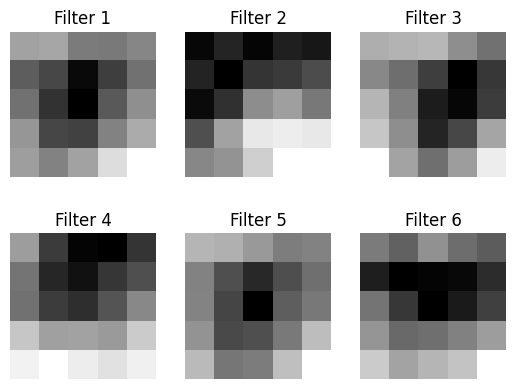

In [ ]:
import matplotlib.pyplot as plt

nrows, ncols = 2, 3
fig, axes = plt.subplots(nrows, ncols)
axes = axes.flatten()

for element in range(nrows * ncols):
  filter = weights_1[:, :, 0, element]
  axes[element].imshow(filter, cmap='gray')
  axes[element].set_title(f"Filter {element + 1}")
  axes[element].axis('off')

plt.show()

Repeat the above for the second convolutional layer:

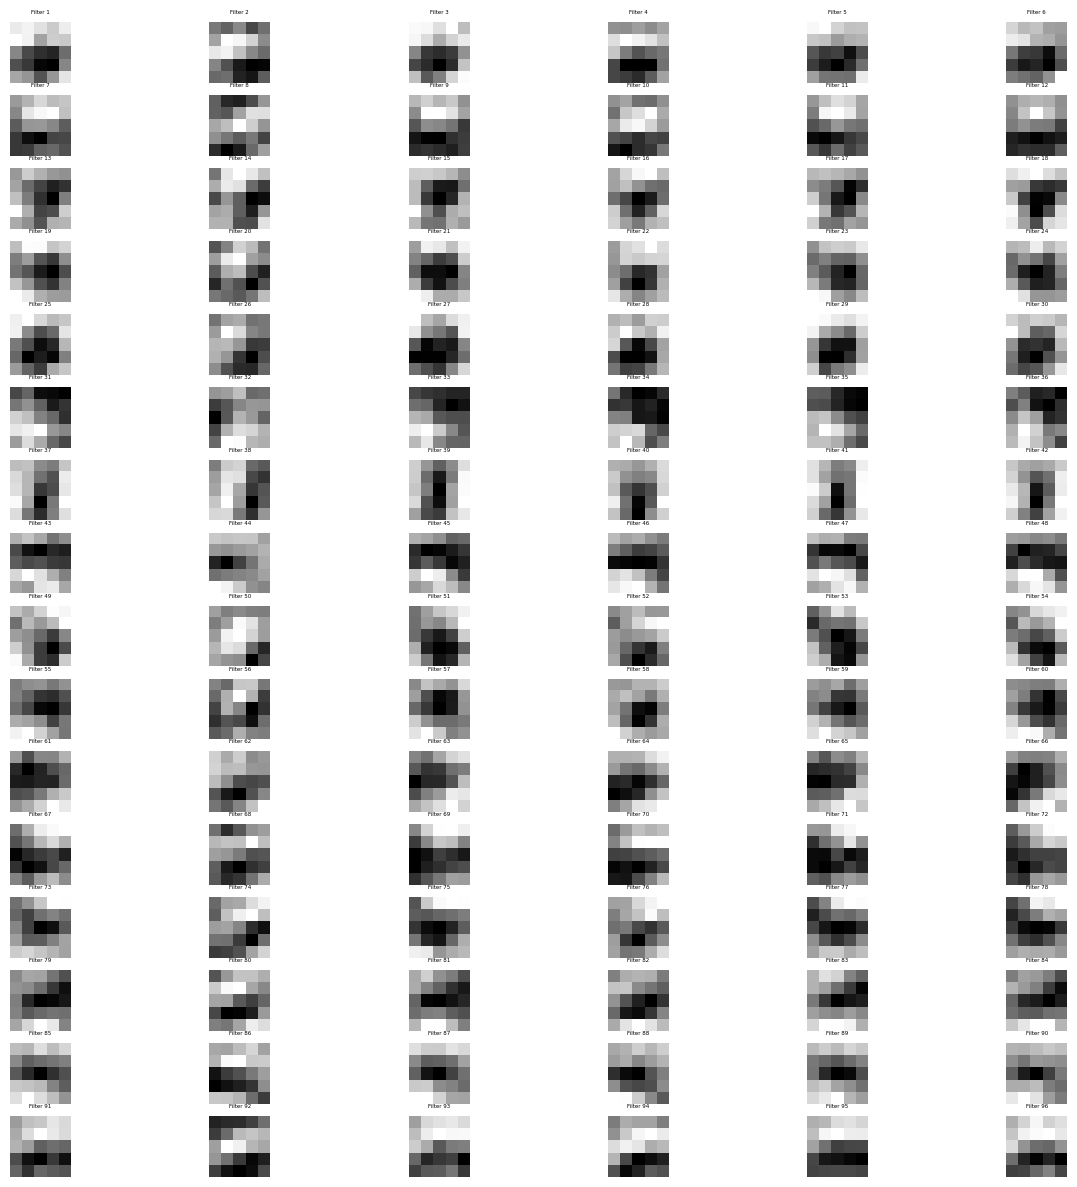

In [ ]:
weights_2 = model.layers[2].get_weights()[0]
nrows, ncols = 16, 6
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 15))

for i in range(16):
  for j in range(6):
    filter = weights_2[:, :, j, i]
    axes[i, j].imshow(filter, cmap='gray')
    axes[i, j].set_title(f"Filter {i * 6 + j + 1}", fontsize=4)
    axes[i, j].axis('off')

plt.show()

Do the *weights* learned by the second convolutional layer look different from the first? How do you expect the *activation* of neurons in the second convolutional layer to differ from the first?

In [ ]:
print("First Convolutional Layer:", weights_1.shape)
print("Second Convolutional Layer:", weights_2.shape)

First Convolutional Layer: (5, 5, 1, 6)
Second Convolutional Layer: (5, 5, 6, 16)


---

**YOUR ANSWER HERE (2 pts):** The weights learned by the second convolutional layer look different from the weights learned by the first convolutional layer. The activation of neurons in the second convolutional layer will usually represent more abstract features in comparison to the first layer. This is because the second layer is building upon the basic features from the first layer, leading to it being more complex. We can see this when comparing the shapes of the weights, as the second convolutional layer has 16 filters, while the first convolutional layer has 6 filters. This results in the second convolutional layer outputting 96 filters.

---

# 4. Extra Credit (3 pts)

Modify the LeNet-5 architecture to improve its performance on CIFAR-10. You can load CIFAR-10 as follows:

```
from keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
```

Justify the changes you make (1 pt), and report the new accuracy (1 pt) along with an explanation of why your modifications helped or didn't help (1 pt).

In [ ]:
from keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(x_train.shape)
print(y_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(50000, 32, 32, 3)
(50000, 10)


In [ ]:
model = keras.Sequential([
    keras.Input(shape=(x_train.shape[0], x_train.shape[1], 1)),

    keras.layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation="relu"),
    keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation="relu"),
    keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2),
    keras.layers.Dropout(0.25),

    keras.layers.Flatten(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer=keras.optimizers.SGD(learning_rate=0.03),
              metrics=['accuracy'])

history = model.fit(X_train, y_train, batch_size=128, epochs=10, validation_split=0.2, callbacks=[EarlyStopping(monitor='val_loss', patience=5)])

In [ ]:
train_results = model.evaluate(X_train, y_train)
test_results = model.evaluate(X_test, y_test)

train_loss = train_results[0]
train_acc = train_results[1]
test_loss = test_results[0]
test_acc = test_results[1]

print("Train Loss:", train_loss)
print("Train Accuracy:", train_acc)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)